In [10]:
import numpy as np
import matplotlib.pyplot as plt

## Parâmetros do sistema

In [11]:
fs = 10000         # Frequência de amostragem (Hz)
Tb = 0.01          # Duração de cada bit (s)
N = int(fs*Tb)     # Número de amostras por bit

f0 = 1000          # Frequência para bit 0 (Hz)
f1 = 2000          # Frequência para bit 1 (Hz)

A = 1              # Amplitude do sinal

num_bits = 10      # Número de bits a serem transmitidos

SNR_dB = 10        # Relação sinal-ruído (dB)

## Geração dos Dados

In [12]:
bits = np.random.randint(0, 2, num_bits)  # Sequência aleatória de bits (0 e 1)

## Geração do sinal FSK

In [13]:
t = np.linspace(0, Tb, N, endpoint=False)  # Vetor de tempo para 1 bit

signal = np.array([])                      # Vetor do sinal transmitido

for bit in bits:
  if bit == 0:
    carrier = A * np.cos(2 * np.pi * f0 * t)   # Sinal para bit 0
  else:
    carrier = A * np.cos(2 * np.pi * f1 * t)   # Sinal para bit 1

  signal = np.concatenate((signal,carrier))    # Junta os sinais

## Adição de Ruído (Canal AWGN)

In [14]:
# Potência do sinal
signal_power = np.mean(signal**2)

# Conversão SNR de dB para linear
SNR_linear = 10**(SNR_dB/10)

# Potência do ruído
noise_power = signal_power/SNR_linear

# Geração do ruído gaussiano
noise = np.sqrt(noise_power)*np.random.randn(len(signal))

# Sinal recebido
received_signal = signal + noise

## Demodulação (Receptor)

In [15]:
received_bits = []

for i in range(num_bits):
  # Segmento correspondente a um bit
  segment = received_signal[i*N:(i+1)*N]

  # Correlacionadores (detecção coerente)
  ref0 = np.cos(2 * np.pi * f0 * t)
  ref1 = np.cos(2 * np.pi * f1 * t)

  # Produto interno (correlação)
  corr0 = np.sum(segment*ref0)
  corr1 = np.sum(segment*ref1)

  # Decisão: escolhe a maior correlação
  if corr1 > corr0:
    received_bits.append(1)
  else:
    received_bits.append(0)

received_bits = np.array(received_bits)

## Resultados

In [16]:
# Calcúlo da taxa de erro de bits (BER)
errors = np.sum(bits != received_bits)
BER = errors/num_bits

print("Bits transmitidos: ", bits)
print("Bits recebidos: ", received_bits)
print("Número de erros: ", errors)
print("BER: ", BER)

Bits transmitidos:  [0 1 1 1 0 1 1 0 0 0]
Bits recebidos:  [0 1 1 1 0 1 1 0 0 0]
Número de erros:  0
BER:  0.0


## Plots

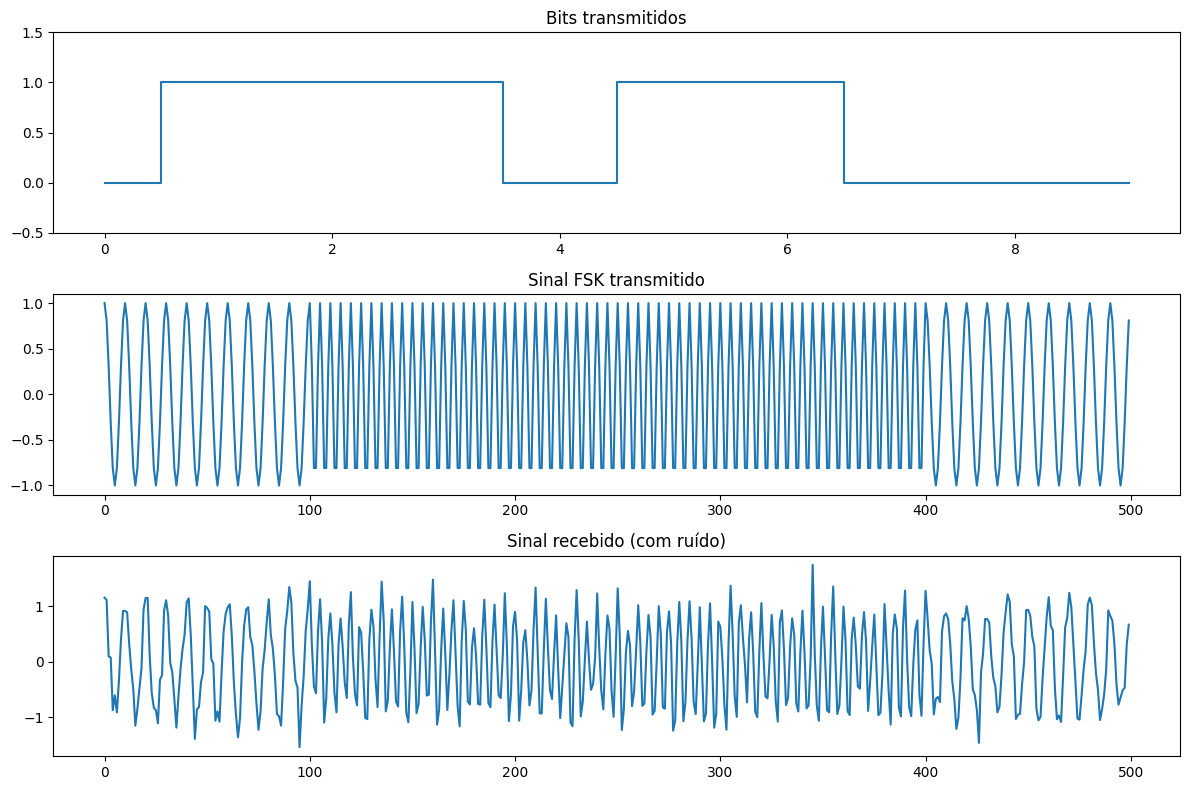

In [17]:
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.title("Bits transmitidos")
plt.step(range(num_bits), bits, where='mid')
plt.ylim(-0.5, 1.5)

plt.subplot(3,1,2)
plt.title("Sinal FSK transmitido")
plt.plot(signal[:5*N])  # Mostra apenas primeiros 5 bits

plt.subplot(3,1,3)
plt.title("Sinal recebido (com ruído)")
plt.plot(received_signal[:5*N])

plt.tight_layout()
plt.show()